#Random Forest

## 1. 전처리 된 데이터셋 불러오기


In [ ]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze("columns") # 표 형태 csv 변환하기
y_test  = pd.read_csv("y_test.csv").squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (98253, 65)  X_test: (24601, 65)


## 2. 모델 학습 - 랜덤 포레스트
- 랜덤 포레스트 : 결정 트리를 랜덤하게 만들어 숲을 만들고 각 결정 트리의 예측을 사용해서 최종 예측을 만드는 모델
- 여러 개의 의사결정 트리를 결합하여 예측 성능을 높이는 대표적인 앙상블 머신러닝 알고리즘임
- 각 노드를 분할할 때 전체 특성 중에서 일부 특성을 무작위로 고른 다음 이 중에서 최선의 분할을 찾음

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

# 랜덤포레스트 학습
rf = RandomForestClassifier(
    n_estimators=300, # 결정트리 개수
    min_samples_leaf=2, # 과적합 방지
    class_weight='balanced', #클래스 불균형 -> 소수 클래스 우대
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# 예측
y_pred  = rf.predict(X_test) # 0/1로 예측 -> 혼동행렬, Accuracy, F1 계산 시 사용
y_proba = rf.predict_proba(X_test)[:, 1] # 확률로 예측 -> roc 커브, auc 그릴때 사용

# 평가
print("=== Random Forest 성능 ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3)) # Accuracy : 전체 중 맞힌 비율
print("Precision:", round(precision_score(y_test, y_pred), 3)) # Precision : 입양이라 예측한 것 중 진짜 입양 비율
print("Recall   :", round(recall_score(y_test, y_pred), 3)) # Recall : 진짜 입양 중 찾아낸 비율
print("F1       :", round(f1_score(y_test, y_pred), 3)) # F1 : precision과 recall의 조화 평균
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 3)) # ROC-AUC : 전체 판별 능력
print()
print(classification_report(y_test, y_pred, digits=3))

=== Random Forest 성능 ===
Accuracy : 0.729
Precision: 0.668
Recall   : 0.781
F1       : 0.72
ROC-AUC  : 0.811

              precision    recall  f1-score   support

           0      0.796     0.688     0.738     13627
           1      0.668     0.781     0.720     10974

    accuracy                          0.729     24601
   macro avg      0.732     0.735     0.729     24601
weighted avg      0.739     0.729     0.730     24601



## 혼동행렬
- 우리는 입양될 앤데 안 될 거라고 예측하는 거(FN) 줄여야함
- 2400으로 가장 적게 놓침

=== 혼동행렬 (숫자) ===
[[9372 4255]
 [2400 8574]]

실제 비입양을 비입양으로 맞힘 : 9,372
실제 비입양을 입양으로 틀림   : 4,255
실제 입양을 비입양으로 틀림   : 2,400
실제 입양을 입양으로 맞힘     : 8,574


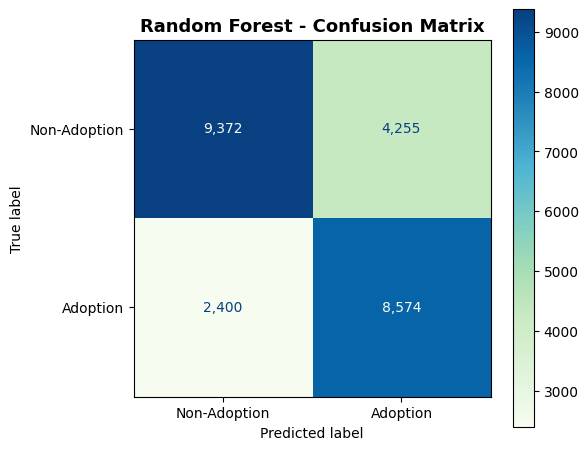

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred)

print("=== 혼동행렬 (숫자) ===")
print(cm)
print()
print(f"실제 비입양을 비입양으로 맞힘 : {cm[0,0]:,}")
print(f"실제 비입양을 입양으로 틀림   : {cm[0,1]:,}")
print(f"실제 입양을 비입양으로 틀림   : {cm[1,0]:,}")
print(f"실제 입양을 입양으로 맞힘     : {cm[1,1]:,}")

# 시각화
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Adoption', 'Adoption']
)
disp.plot(ax=ax, cmap='GnBu', values_format=',d', colorbar=True)
plt.title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## feature importance
- 모델이 어떤 변수를 보고 판단했는지 알려주는 지표
- 전체 변수 중 상위 15개만 뽑음

=== 상위 15 중요 변수 ===
age_days                        0.1729
has_name                        0.0967
intake_month                    0.0747
sex_Unknown                     0.0476
sterilized_status_Unknown       0.0455
Intake Type_Owner Surrender     0.0429
Intake Type_Public Assist       0.0413
sterilized_status_Sterilized    0.0320
Animal Type_intake_Dog          0.0291
sex_Male                        0.0259
Intake Type_Stray               0.0241
Intake Condition_Normal         0.0219
color_grouped_Other             0.0184
is_mixed_breed                  0.0175
breed_grouped_Other             0.0165
dtype: float64


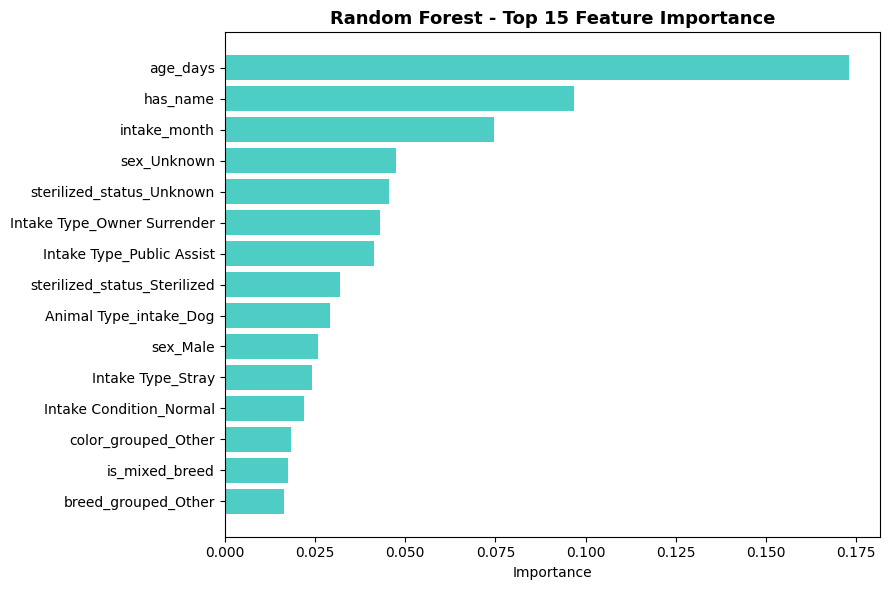

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance 추출
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

print("=== 상위 15 중요 변수 ===")
print(top15.round(4))

# 시각화
plt.figure(figsize=(9, 6))
plt.barh(top15.index[::-1], top15.values[::-1], color='ㅁ')
plt.title('Random Forest - Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## ROC Curve

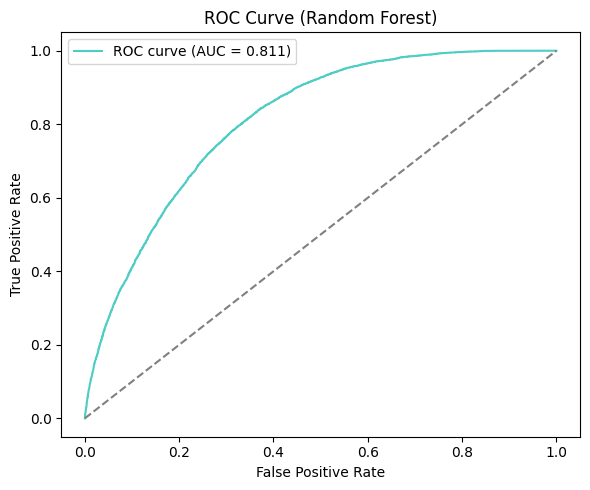

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#4ecdc4",
         label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=120)   # RandomForest ROC curve
plt.show()